# La Liga match prediction


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (12, 5)
pd.set_option('display.max_columns', None)
%matplotlib inline

## Data

In [2]:
from src.data_loader import load_la_liga_matches, LoadSpec

df = load_la_liga_matches(LoadSpec(league="la_liga"))

print(f"{len(df)} matches, {df['home_team'].nunique()} teams")
print(f"seasons {sorted(df['season'].unique())}")
df[['date', 'home_team', 'away_team', 'home_goals', 'away_goals',
    'odds_home', 'odds_draw', 'odds_away']].head()

2280 matches, 27 teams
seasons ['1920', '2021', '2122', '2223', '2324', '2425']


,date,home_team,away_team,home_goals,away_goals,odds_home,odds_draw,odds_away
0,2019-08-16,Ath Bilbao,Barcelona,1,0,5.07,3.81,1.71
1,2019-08-17,Celta,Real Madrid,1,3,4.67,4.12,1.69
2,2019-08-17,Valencia,Sociedad,1,1,1.68,3.80,5.29
3,2019-08-17,Mallorca,Eibar,2,1,2.91,3.09,2.62
4,2019-08-17,Leganes,Osasuna,0,1,2.06,3.18,4.02


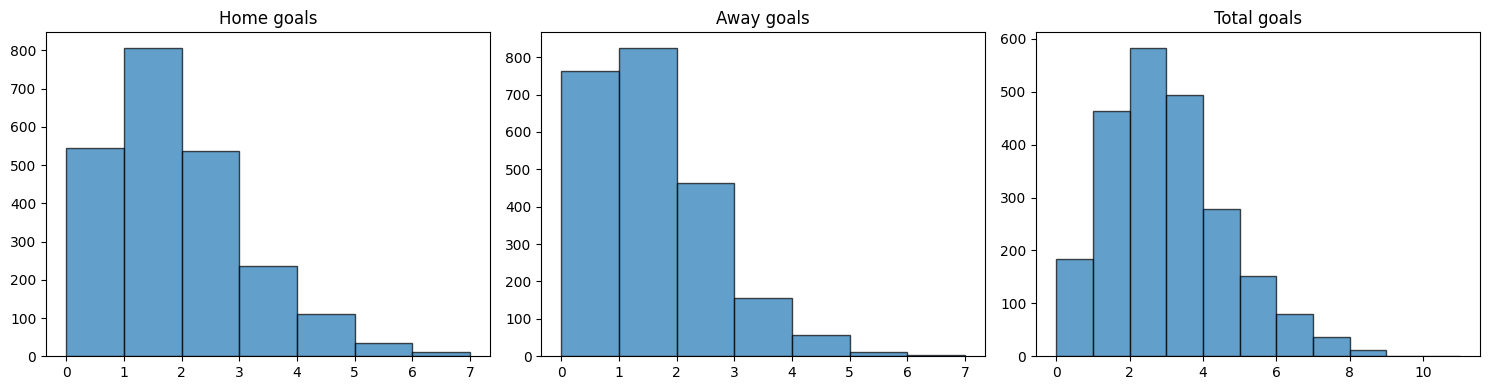

home 1.44  away 1.11  diff +0.33


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(df['home_goals'], bins=range(0, 8), alpha=0.7, edgecolor='black')
axes[0].set_title('Home goals')

axes[1].hist(df['away_goals'], bins=range(0, 8), alpha=0.7, edgecolor='black')
axes[1].set_title('Away goals')

axes[2].hist(df['home_goals'] + df['away_goals'], bins=range(0, 12), alpha=0.7, edgecolor='black')
axes[2].set_title('Total goals')

plt.tight_layout()
plt.show()

print(f"home {df['home_goals'].mean():.2f}  away {df['away_goals'].mean():.2f}  "
      f"diff {df['home_goals'].mean() - df['away_goals'].mean():+.2f}")

## De-vigging

avg overround 4.58%


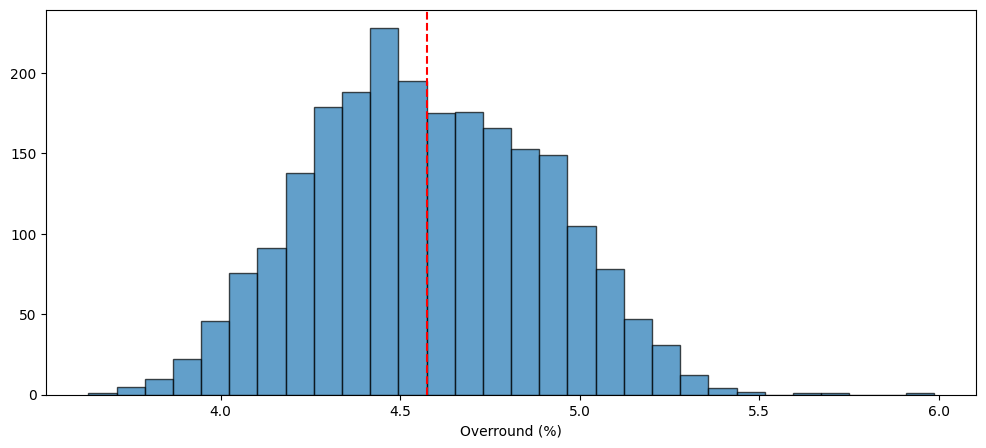

In [4]:
from src.odds import add_market_probs
from src.evaluation import add_true_outcome

df = add_market_probs(df)
df = add_true_outcome(df)

print(f"avg overround {df['market_overround'].mean()*100:.2f}%")

plt.hist(df['market_overround'] * 100, bins=30, alpha=0.7, edgecolor='black')
plt.axvline(df['market_overround'].mean() * 100, color='red', linestyle='--')
plt.xlabel('Overround (%)')
plt.show()

## Split

In [5]:
from src.pipeline import split_data

splits = split_data(df)
train_df, val_df, test_df = splits['train'], splits['val'], splits['test']

print(f"train {len(train_df)} (1920-2223)")
print(f"val   {len(val_df)} (2324)")
print(f"test  {len(test_df)} (2425)")

train 1520 (1920-2223)
val   380 (2324)
test  380 (2425)


## Fit

In [6]:
from src.model import PoissonStrengthModel

train_combined = pd.concat([train_df, val_df], ignore_index=True)
model = PoissonStrengthModel(reg=1.0, home_adv=0.10).fit(train_combined)

mu, home_adv, attack, defense = model._unpack(model.params_, len(model.teams_))
print(f"mu         {mu:.3f}")
print(f"home_adv   {home_adv:.3f}  ({(np.exp(home_adv)-1)*100:.1f}% more goals)")

mu         0.027
home_adv   0.268  (30.7% more goals)


## Team strengths

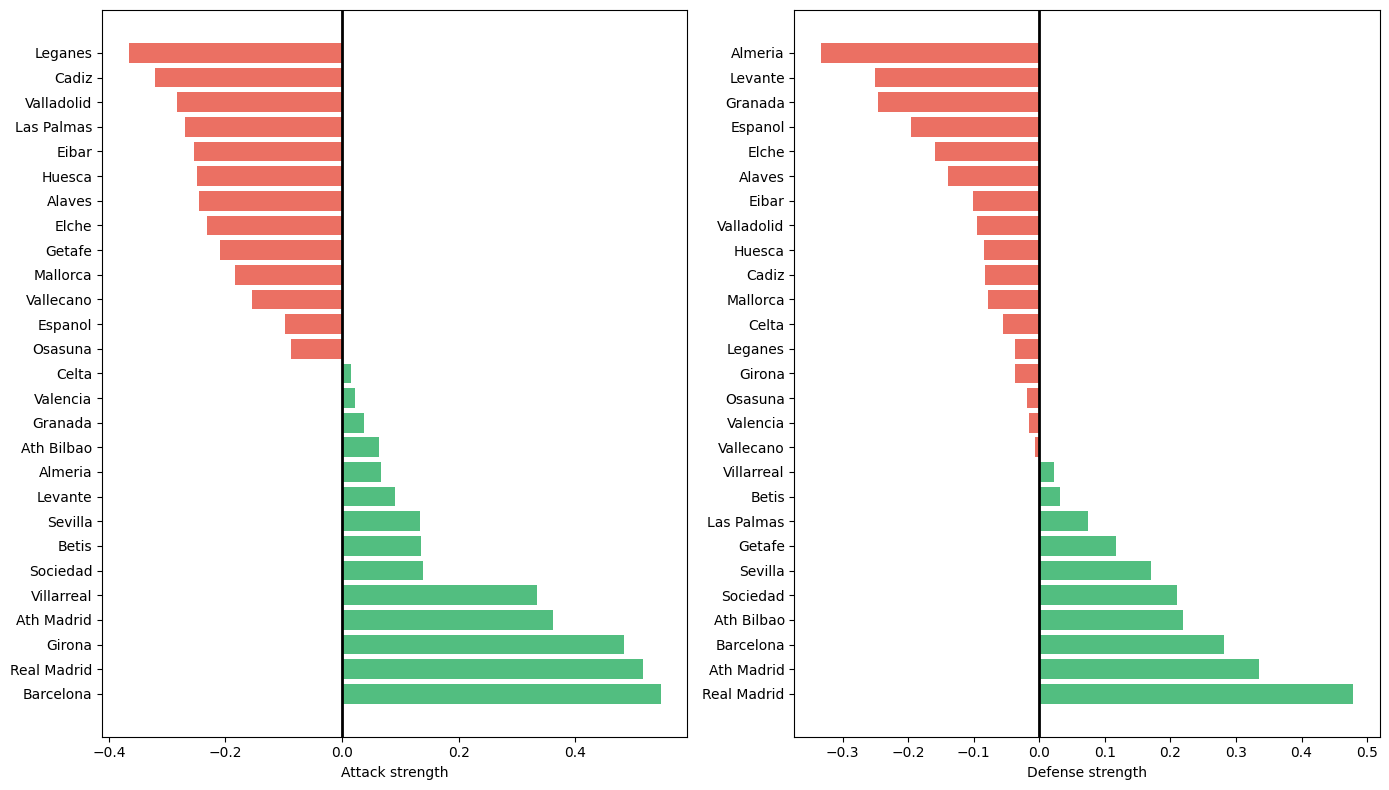

       Team   Attack   Defense
  Barcelona 0.546694  0.281424
Real Madrid 0.516185  0.478809
     Girona 0.483559 -0.037154
 Ath Madrid 0.361834  0.335300
 Villarreal 0.334784  0.022967


In [7]:
teams_df = pd.DataFrame({
    'Team': model.teams_,
    'Attack': attack,
    'Defense': -defense
}).sort_values('Attack', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 8))

colors_attack = ['#27ae60' if x > 0 else '#e74c3c' for x in teams_df['Attack']]
axes[0].barh(teams_df['Team'], teams_df['Attack'], color=colors_attack, alpha=0.8)
axes[0].axvline(x=0, color='black', linewidth=2)
axes[0].set_xlabel('Attack strength')

teams_def = teams_df.sort_values('Defense', ascending=False)
colors_def = ['#27ae60' if x > 0 else '#e74c3c' for x in teams_def['Defense']]
axes[1].barh(teams_def['Team'], teams_def['Defense'], color=colors_def, alpha=0.8)
axes[1].axvline(x=0, color='black', linewidth=2)
axes[1].set_xlabel('Defense strength')

plt.tight_layout()
plt.show()

print(teams_df.head().to_string(index=False))

## Test predictions (2024/25)

In [8]:
from src.pipeline import predict_matches

test_df = predict_matches(model, test_df)

test_df[['date', 'home_team', 'away_team', 'home_goals', 'away_goals',
         'p_home_model', 'p_draw_model', 'p_away_model']].head(10)

,date,home_team,away_team,home_goals,away_goals,p_home_model,p_draw_model,p_away_model
1900,2024-08-15,Betis,Girona,1,1,0.379278,0.233723,0.386999
1901,2024-08-15,Ath Bilbao,Getafe,1,1,0.509881,0.294141,0.195979
1902,2024-08-16,Las Palmas,Sevilla,2,2,0.285859,0.310028,0.404113
1903,2024-08-16,Celta,Alaves,2,1,0.542873,0.253758,0.203369
1904,2024-08-17,Osasuna,Leganes,1,1,0.495795,0.292225,0.211981
1905,2024-08-17,Valencia,Barcelona,1,2,0.215935,0.230567,0.553498
1906,2024-08-18,Sociedad,Vallecano,1,2,0.575121,0.254270,0.170609
1907,2024-08-18,Mallorca,Real Madrid,1,1,0.132049,0.215465,0.652486
1908,2024-08-19,Valladolid,Espanol,1,0,0.408622,0.284961,0.306417
1909,2024-08-19,Villarreal,Ath Madrid,2,2,0.350773,0.253264,0.395963


In [9]:
from src.evaluation import summarize_probs

test_complete = test_df.dropna(subset=['p_home_model'])

model_probs = test_complete[['p_home_model', 'p_draw_model', 'p_away_model']].values
market_probs = test_complete[['market_p_home', 'market_p_draw', 'market_p_away']].values
y_true = test_complete['y_true'].values

model_metrics = summarize_probs(model_probs, y_true)
market_metrics = summarize_probs(market_probs, y_true)

print(f"model   log_loss {model_metrics['log_loss']:.4f}  brier {model_metrics['brier']:.4f}")
print(f"market  log_loss {market_metrics['log_loss']:.4f}  brier {market_metrics['brier']:.4f}")

model   log_loss 0.9911  brier 0.5908
market  log_loss 0.9532  brier 0.5639


## Calibration

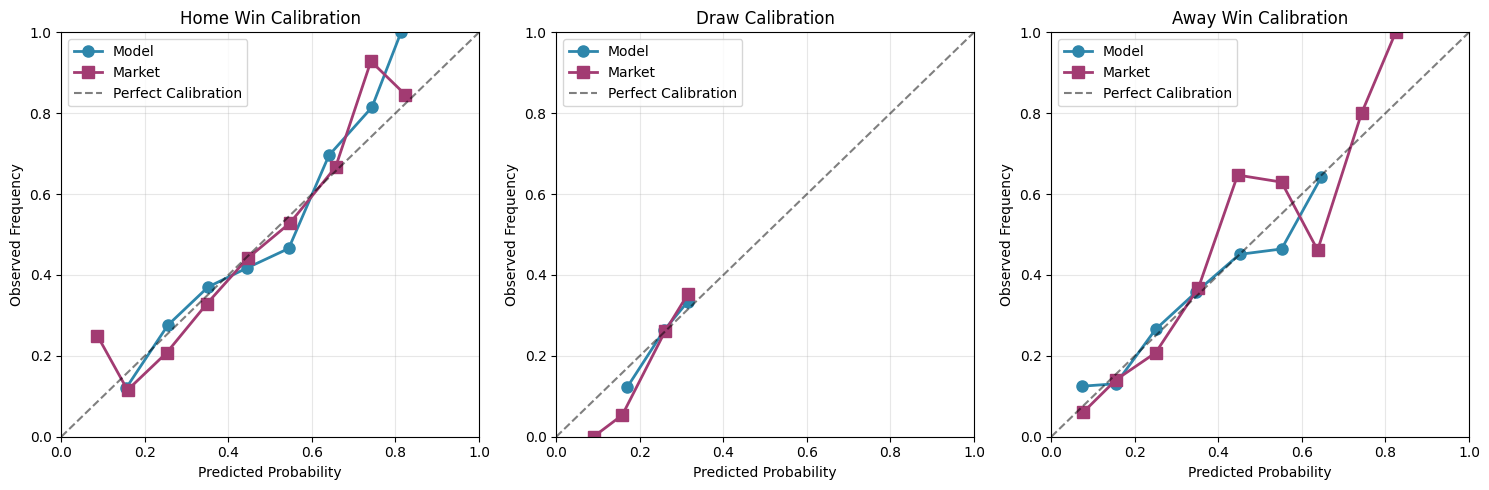

In [10]:
from analysis.viz import plot_calibration_curves

fig = plot_calibration_curves(model_probs, market_probs, y_true)
plt.show()

## Model vs market

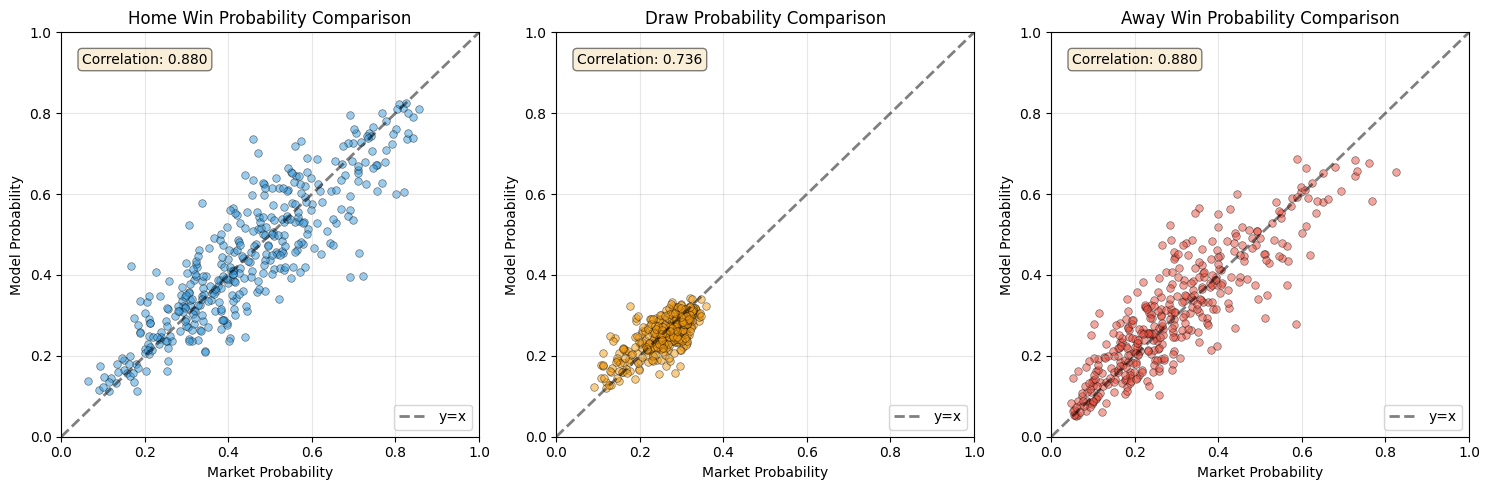

home   corr 0.880
draw   corr 0.736
away   corr 0.880


In [11]:
from analysis.viz import plot_model_vs_market

fig = plot_model_vs_market(test_complete)
plt.show()

for outcome in ['home', 'draw', 'away']:
    corr = test_complete[f'p_{outcome}_model'].corr(test_complete[f'market_p_{outcome}'])
    print(f"{outcome:6} corr {corr:.3f}")

## EV

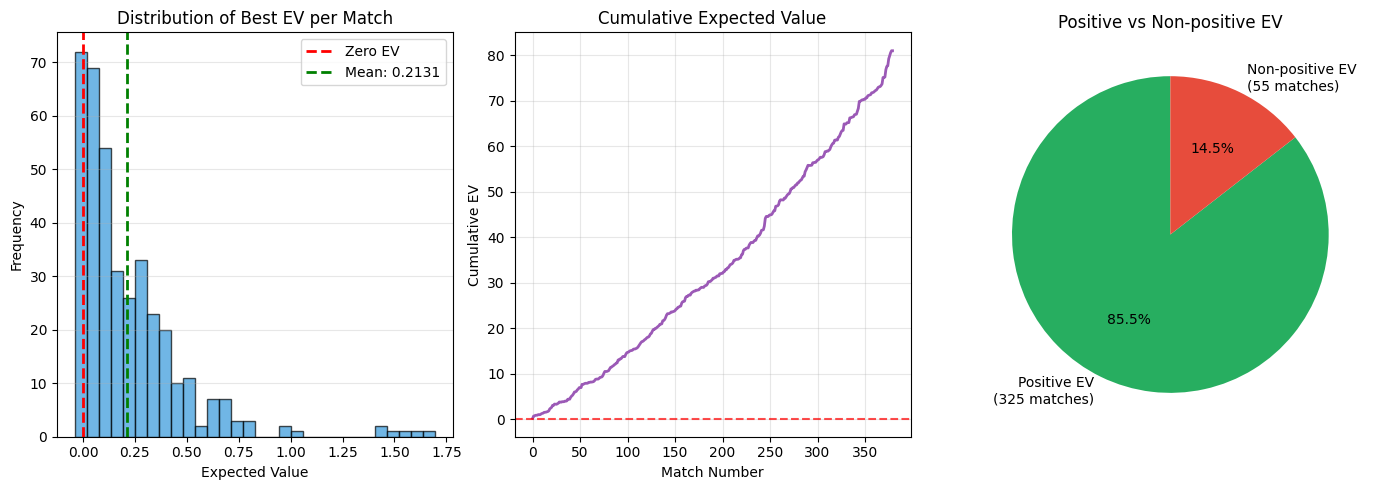

mean 0.2131  median 0.1305  std 0.2625
positive 325/380 (85.5%)


In [12]:
from analysis.viz import plot_ev_distribution

fig = plot_ev_distribution(test_complete)
plt.show()

positive = (test_complete['best_ev'] > 0).sum()
print(f"mean {test_complete['best_ev'].mean():.4f}  median {test_complete['best_ev'].median():.4f}  "
      f"std {test_complete['best_ev'].std():.4f}")
print(f"positive {positive}/{len(test_complete)} ({positive/len(test_complete)*100:.1f}%)")

## Per-team

In [13]:
from analysis.analysis import per_team_analysis

team_perf = per_team_analysis(test_complete)
print(team_perf[['team', 'matches', 'wins', 'expected_wins', 'win_diff',
                 'expected_win_pct', 'win_pct']].to_string(index=False))

       team  matches  wins  expected_wins  win_diff  expected_win_pct  win_pct
  Barcelona       38    28      23.065730  4.934270          0.606993 0.736842
Real Madrid       38    26      24.234189  1.765811          0.637742 0.684211
 Ath Madrid       38    22      20.729308  1.270692          0.545508 0.578947
 Villarreal       38    20      17.385566  2.614434          0.457515 0.526316
 Ath Bilbao       38    19      15.500054  3.499946          0.407896 0.500000
      Betis       38    16      14.728852  1.271148          0.387601 0.421053
      Celta       38    16      12.415785  3.584215          0.326731 0.421053
   Sociedad       38    13      16.437020 -3.437020          0.432553 0.342105
   Mallorca       38    13      10.044375  2.955625          0.264326 0.342105
  Vallecano       38    13      10.955911  2.044089          0.288313 0.342105
    Osasuna       38    12      11.558759  0.441241          0.304178 0.315789
    Espanol       38    11       9.858400  1.141600 

In [14]:
from analysis.analysis import export_team_strengths

strengths = export_team_strengths(model, 'team_strengths.csv')
strengths.head()

,team,attack_strength,defense_strength,expected_goals_scored,expected_goals_conceded
4,Barcelona,0.546694,0.281424,2.320398,1.361429
20,Real Madrid,0.516185,0.478809,2.250673,1.658511
12,Girona,0.483559,-0.037154,2.178427,0.990008
3,Ath Madrid,0.361834,0.335300,1.928762,1.436790
26,Villarreal,0.334784,0.022967,1.877287,1.051353
